# 🚂 Sysslan IT Solutions — Internship Project
## Level 4: Visualization & Pattern Analysis
**Project:** Train Route Analysis and Journey Time Prediction  
**Level:** 4 — Visualization & Pattern Analysis  
**Dataset:** Indian Railways Train Schedule  
---

## 📦 Step 0: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print('✅ Libraries imported!')

✅ Libraries imported!


In [2]:
# Load cleaned data from Level 2
train_master = pd.read_csv('train_master_cleaned.csv')
df_clean     = pd.read_csv('dataset_cleaned.csv')

# Recreate helper columns
def duration_category(hrs):
    if hrs <= 2:    return 'Short (≤2 hrs)'
    elif hrs <= 8:  return 'Medium (2–8 hrs)'
    elif hrs <= 18: return 'Long (8–18 hrs)'
    else:           return 'Very Long (>18 hrs)'

train_master['Duration_Category'] = train_master['Journey_Duration_Hrs'].apply(duration_category)

bins   = [0, 100, 300, 600, 1000, 2000, 5000]
labels = ['0–100km', '100–300km', '300–600km', '600–1000km', '1000–2000km', '2000km+']
train_master['Distance_Bucket'] = pd.cut(train_master['Total_Distance_km'], bins=bins, labels=labels)

station_traffic = df_clean.groupby(['Station_Code', 'Station_Name'])['Train_No'] \
    .nunique().reset_index()
station_traffic.columns = ['Station_Code', 'Station_Name', 'Train_Count']
station_traffic = station_traffic.sort_values('Train_Count', ascending=False).reset_index(drop=True)

print(f'✅ train_master : {train_master.shape[0]:,} trains')
print(f'✅ df_clean     : {df_clean.shape[0]:,} rows')
print(f'✅ station_traffic : {len(station_traffic):,} stations')

✅ train_master : 10,625 trains
✅ df_clean     : 186,074 rows
✅ station_traffic : 8,150 stations


---
## 📊 Task 4.1 — Visualize Journey Duration Across Different Routes

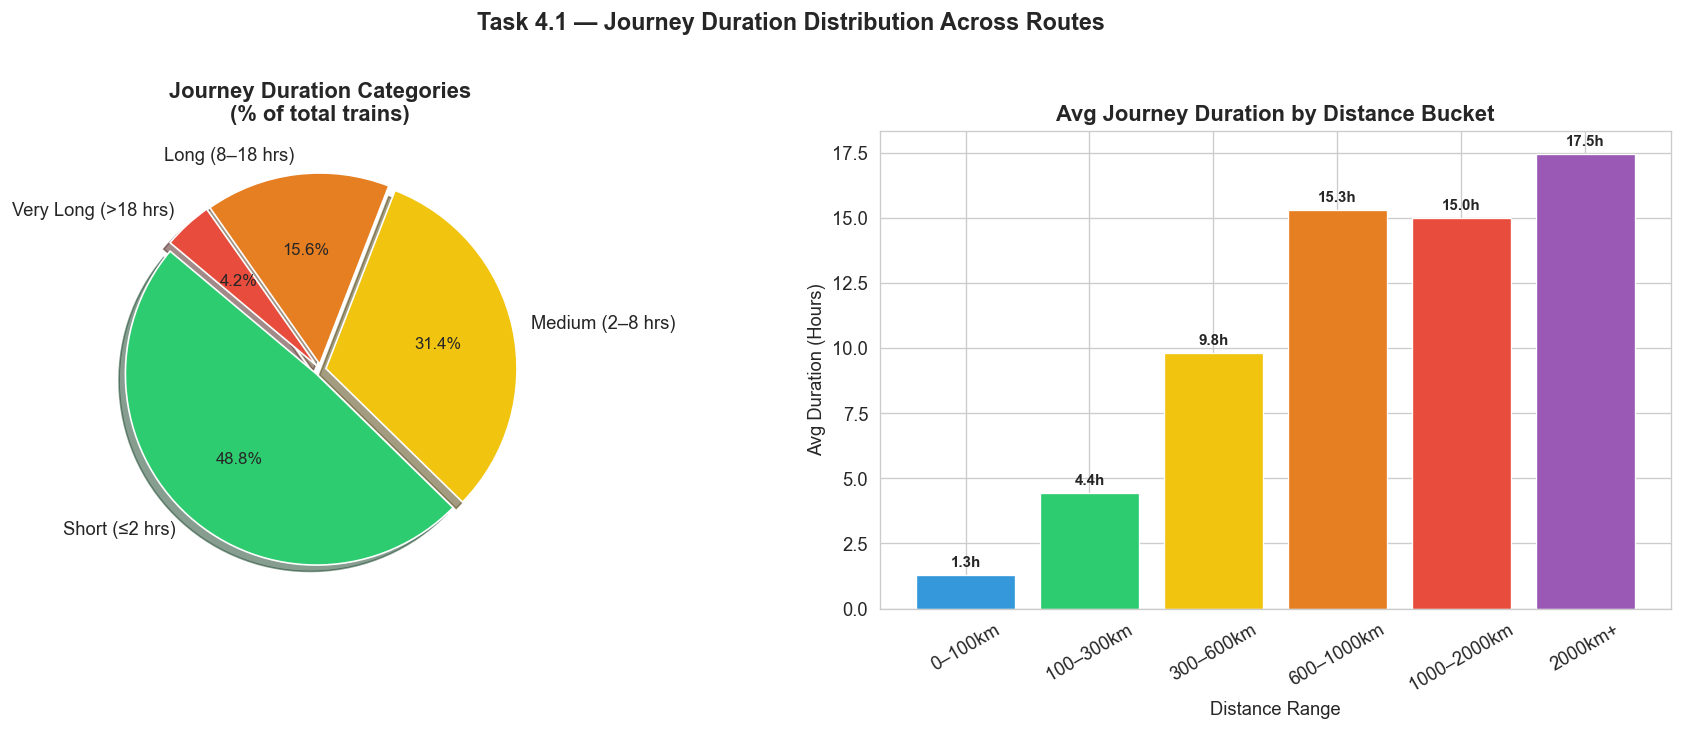

✅ Chart 1 saved!


In [3]:
# --- Chart 1: Pie Chart — Duration Category Distribution ---
cat_order  = ['Short (≤2 hrs)', 'Medium (2–8 hrs)', 'Long (8–18 hrs)', 'Very Long (>18 hrs)']
cat_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
cat_counts = train_master['Duration_Category'].value_counts().reindex(cat_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Task 4.1 — Journey Duration Distribution Across Routes', fontsize=14, fontweight='bold', y=1.01)

# Pie chart
wedges, texts, autotexts = axes[0].pie(
    cat_counts,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    colors=cat_colors,
    startangle=140,
    explode=[0.03]*4,
    shadow=True
)
for at in autotexts: at.set_fontsize(10)
axes[0].set_title('Journey Duration Categories\n(% of total trains)', fontweight='bold')

# Bar chart — avg duration per distance bucket
bucket_avg = train_master.groupby('Distance_Bucket', observed=True)['Journey_Duration_Hrs'].mean()
bars = axes[1].bar(bucket_avg.index, bucket_avg.values,
                   color=['#3498db','#2ecc71','#f1c40f','#e67e22','#e74c3c','#9b59b6'],
                   edgecolor='white', linewidth=0.8)
axes[1].set_title('Avg Journey Duration by Distance Bucket', fontweight='bold')
axes[1].set_xlabel('Distance Range')
axes[1].set_ylabel('Avg Duration (Hours)')
axes[1].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.1f}h', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Level4_Chart1_Duration_Routes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved!')

C:\Users\spr49\AppData\Local\Temp\ipykernel_38432\607483028.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


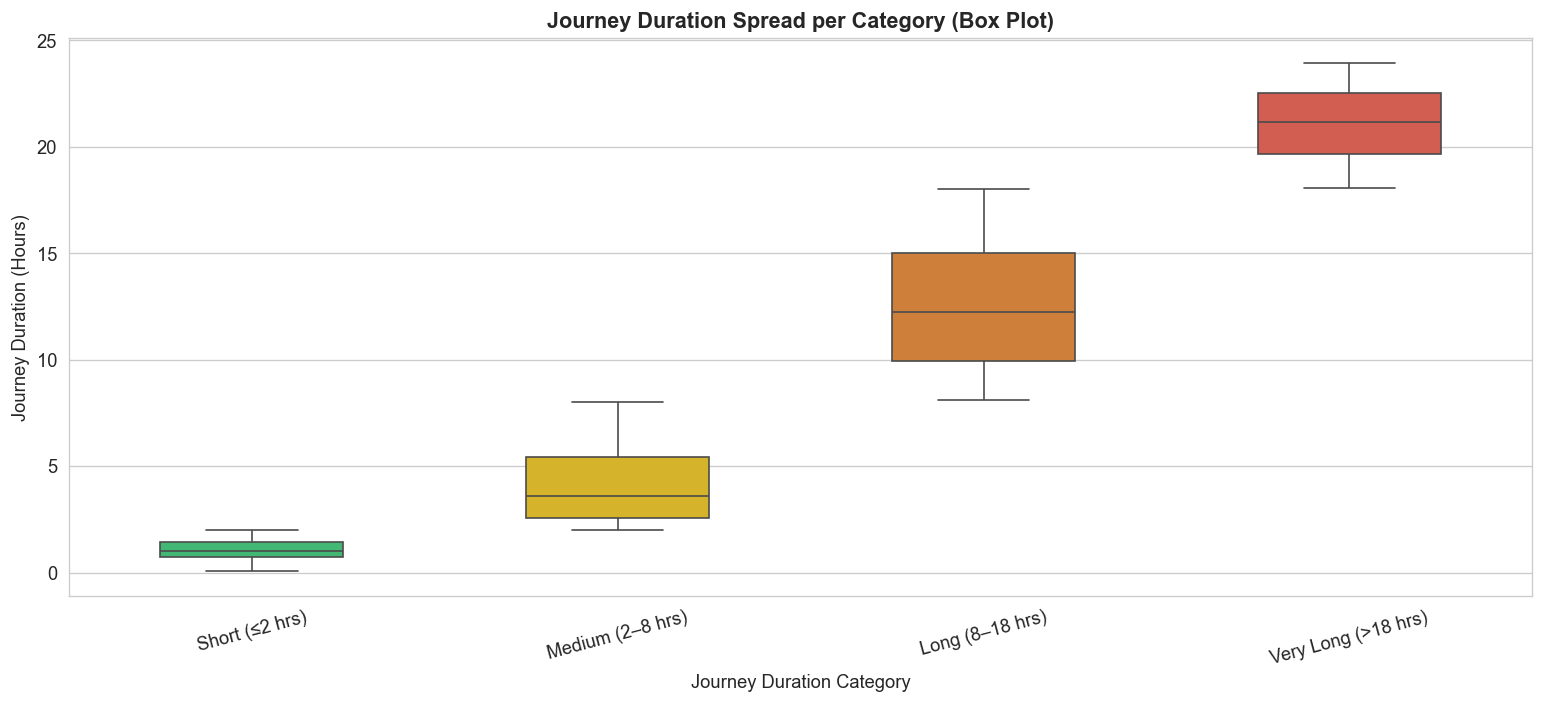

✅ Chart 2 saved!


In [5]:
# --- Chart 2: Box Plot — Duration spread per category ---
cat_order2 = ['Short (≤2 hrs)', 'Medium (2–8 hrs)', 'Long (8–18 hrs)', 'Very Long (>18 hrs)']

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=train_master,
    x='Duration_Category',
    y='Journey_Duration_Hrs',
    order=cat_order2,
    palette=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'],
    width=0.5,
    ax=ax
)
ax.set_title('Journey Duration Spread per Category (Box Plot)', fontsize=13, fontweight='bold')
ax.set_xlabel('Journey Duration Category')
ax.set_ylabel('Journey Duration (Hours)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('Level4_Chart2_Duration_Boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved!')

---
## 🚉 Task 4.2 — Station-wise Train Traffic Charts

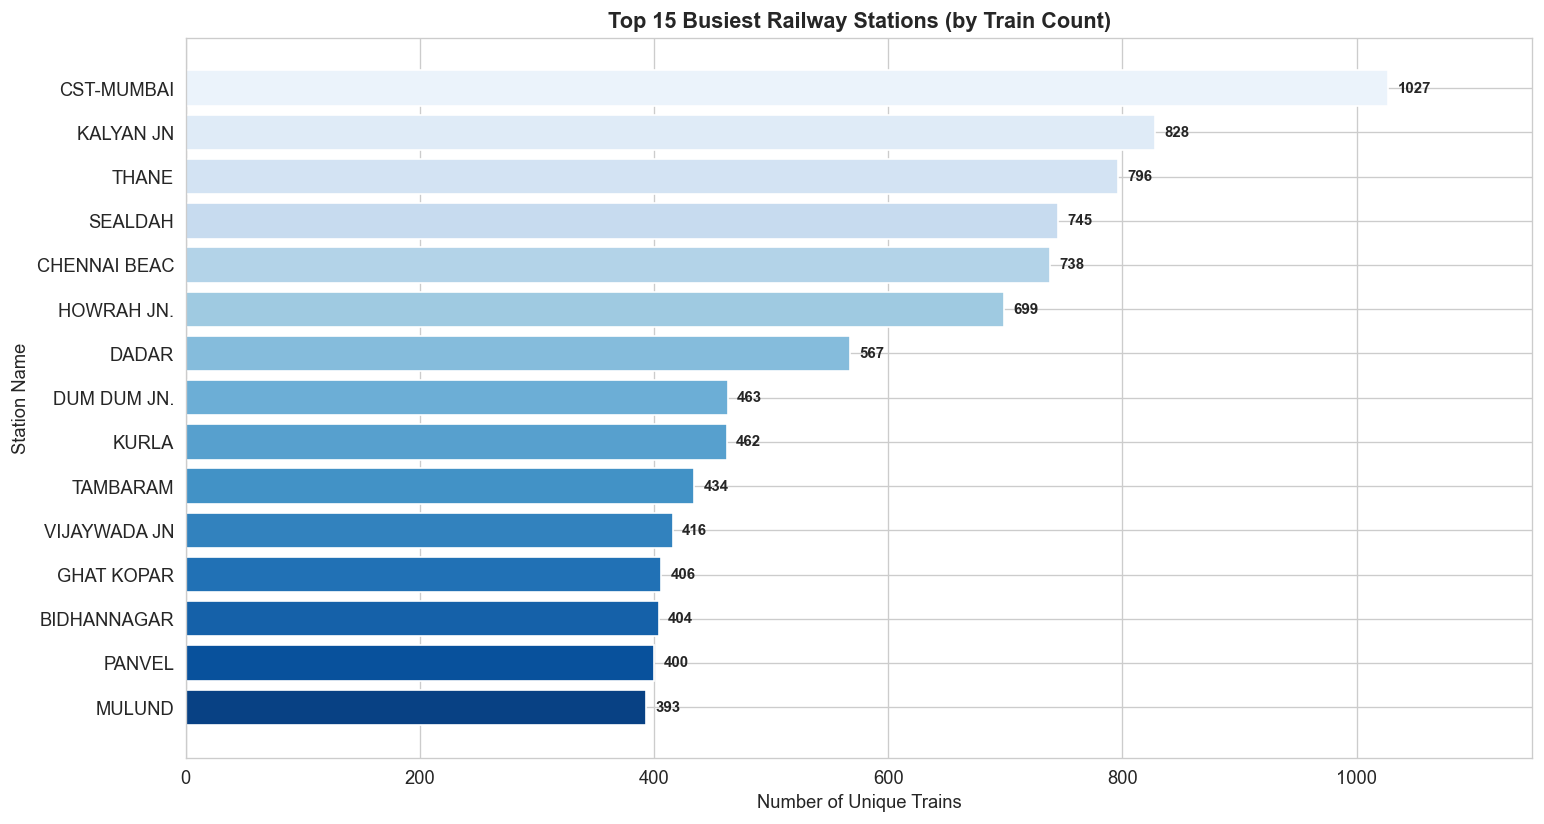

✅ Chart 3 saved!


In [6]:
# --- Chart 3: Top 15 Busiest Stations (Horizontal Bar) ---
top15 = station_traffic.head(15)

fig, ax = plt.subplots(figsize=(13, 7))
colors = sns.color_palette('Blues_r', len(top15))
bars = ax.barh(top15['Station_Name'][::-1], top15['Train_Count'][::-1],
               color=colors, edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width())}", va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 15 Busiest Railway Stations (by Train Count)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Unique Trains')
ax.set_ylabel('Station Name')
ax.set_xlim(0, top15['Train_Count'].max() * 1.12)

plt.tight_layout()
plt.savefig('Level4_Chart3_Station_Traffic_Top15.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved!')

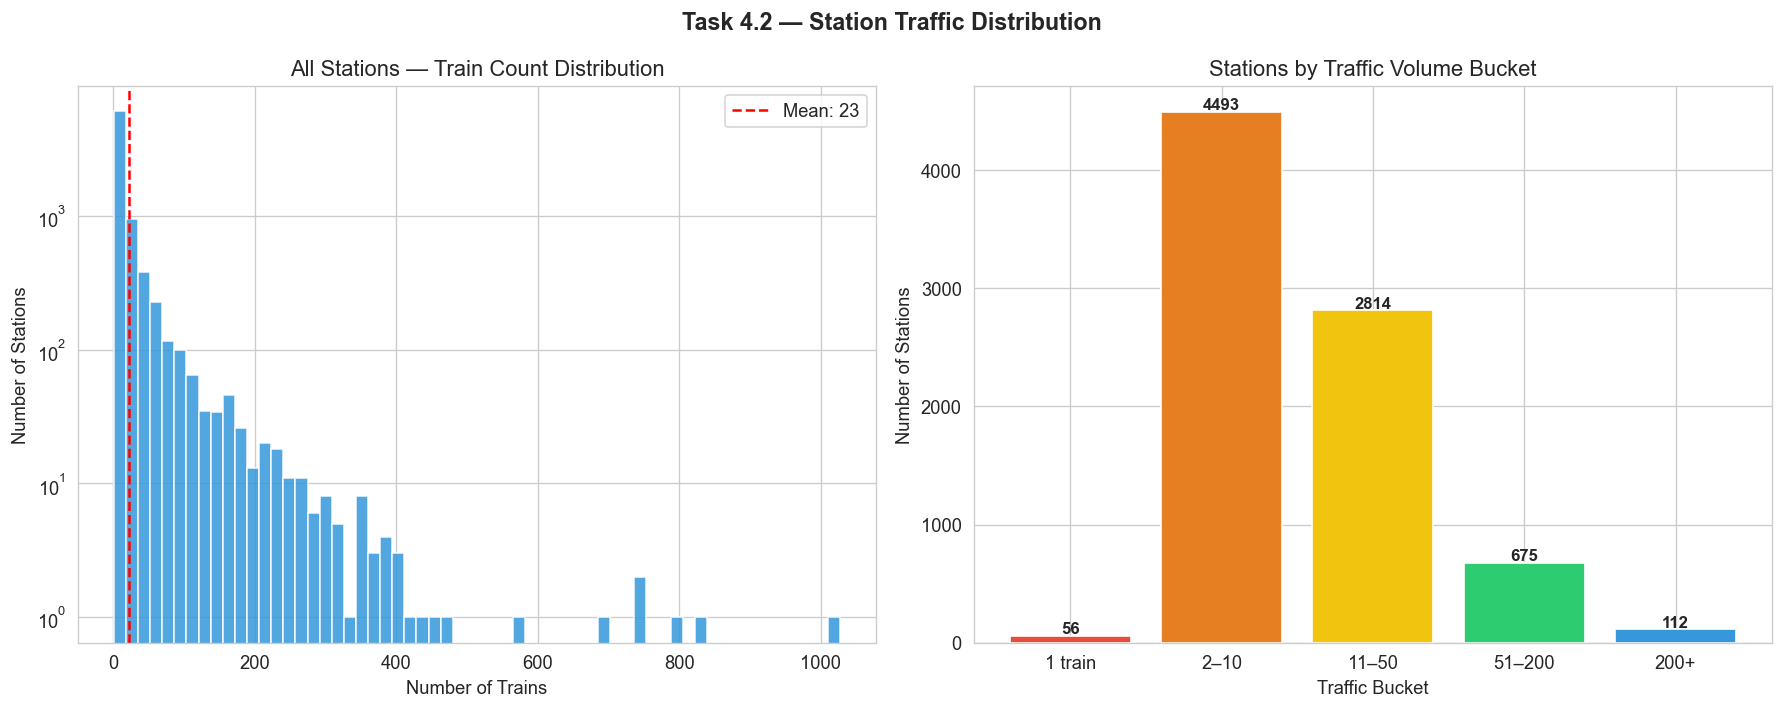

✅ Chart 4 saved!


In [7]:
# --- Chart 4: Station Traffic Distribution Histogram ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Task 4.2 — Station Traffic Distribution', fontsize=14, fontweight='bold')

# Full distribution (log scale)
axes[0].hist(station_traffic['Train_Count'], bins=60,
             color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('All Stations — Train Count Distribution')
axes[0].set_xlabel('Number of Trains')
axes[0].set_ylabel('Number of Stations')
axes[0].set_yscale('log')
axes[0].axvline(station_traffic['Train_Count'].mean(), color='red',
                linestyle='--', label=f"Mean: {station_traffic['Train_Count'].mean():.0f}")
axes[0].legend()

# Traffic bucket breakdown
traffic_buckets = {
    '1 train':    (station_traffic['Train_Count'] == 1).sum(),
    '2–10':       station_traffic['Train_Count'].between(2, 10).sum(),
    '11–50':      station_traffic['Train_Count'].between(11, 50).sum(),
    '51–200':     station_traffic['Train_Count'].between(51, 200).sum(),
    '200+':       (station_traffic['Train_Count'] > 200).sum()
}
tb_df = pd.Series(traffic_buckets)
axes[1].bar(tb_df.index, tb_df.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'],
            edgecolor='white')
axes[1].set_title('Stations by Traffic Volume Bucket')
axes[1].set_xlabel('Traffic Bucket')
axes[1].set_ylabel('Number of Stations')
for i, (k, v) in enumerate(traffic_buckets.items()):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('Level4_Chart4_Station_Traffic_Dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 4 saved!')

---
## 📈 Task 4.3 — Distance vs Journey Duration Plot

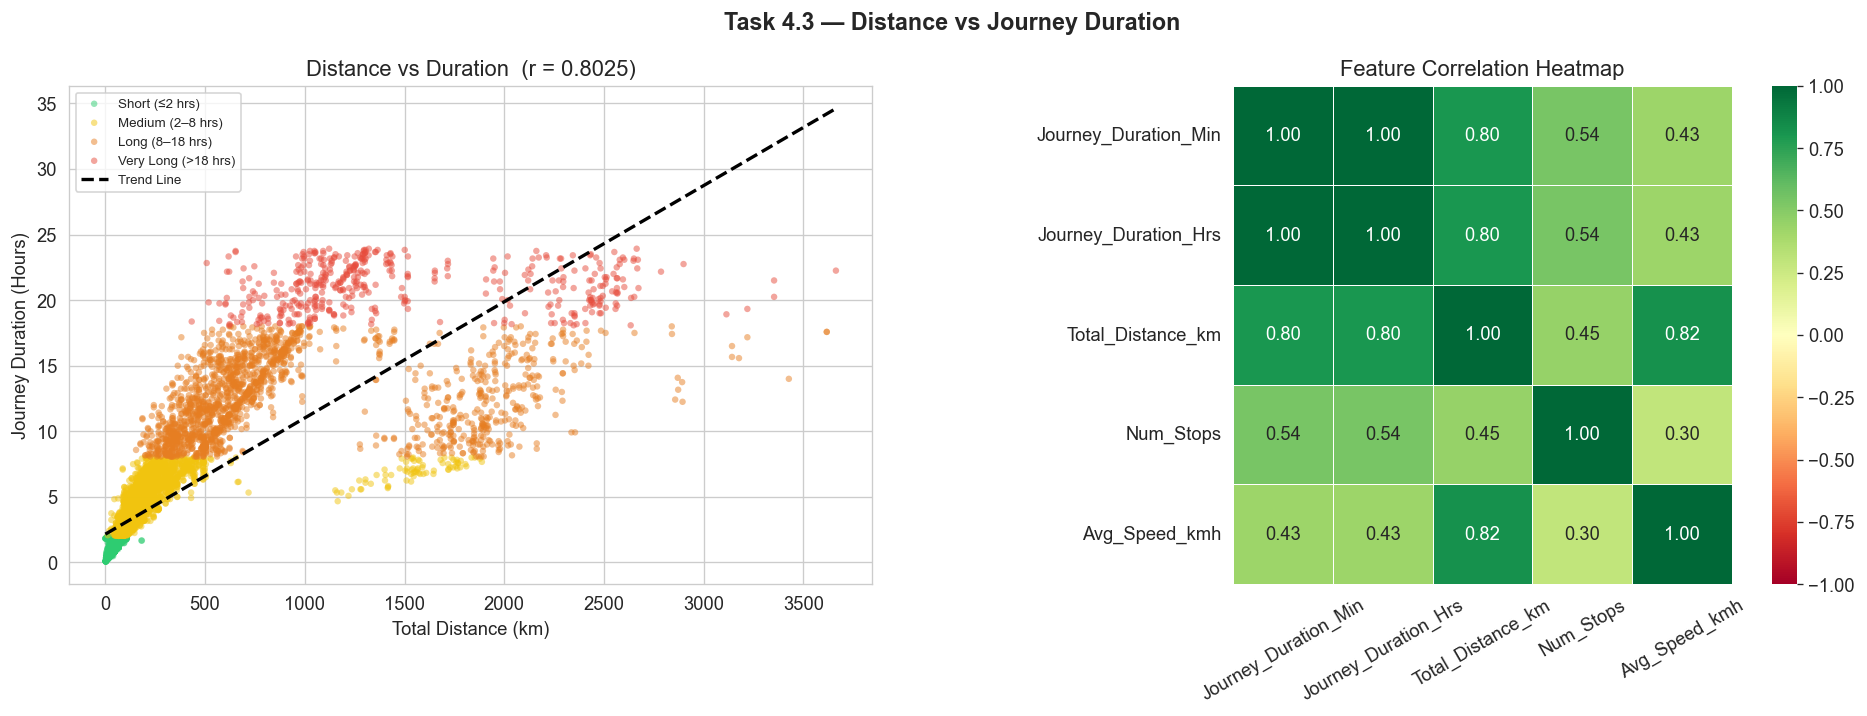

✅ Chart 5 saved!


In [8]:
# --- Chart 5: Scatter Plot — Distance vs Duration ---
cat_color_map = {
    'Short (≤2 hrs)':    '#2ecc71',
    'Medium (2–8 hrs)':  '#f1c40f',
    'Long (8–18 hrs)':   '#e67e22',
    'Very Long (>18 hrs)':'#e74c3c'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Task 4.3 — Distance vs Journey Duration', fontsize=14, fontweight='bold')

# Scatter — colored by duration category
for cat, color in cat_color_map.items():
    subset = train_master[train_master['Duration_Category'] == cat]
    axes[0].scatter(subset['Total_Distance_km'], subset['Journey_Duration_Hrs'],
                    c=color, label=cat, alpha=0.5, s=15, edgecolors='none')

# Regression line
z = np.polyfit(train_master['Total_Distance_km'], train_master['Journey_Duration_Hrs'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, train_master['Total_Distance_km'].max(), 200)
axes[0].plot(x_line, p(x_line), 'k--', linewidth=2, label='Trend Line')

corr = train_master['Total_Distance_km'].corr(train_master['Journey_Duration_Hrs'])
axes[0].set_title(f'Distance vs Duration  (r = {corr:.4f})')
axes[0].set_xlabel('Total Distance (km)')
axes[0].set_ylabel('Journey Duration (Hours)')
axes[0].legend(fontsize=8, loc='upper left')

# Correlation Heatmap
corr_cols = ['Journey_Duration_Min', 'Journey_Duration_Hrs',
             'Total_Distance_km', 'Num_Stops', 'Avg_Speed_kmh']
corr_matrix = train_master[corr_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Feature Correlation Heatmap')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('Level4_Chart5_Distance_vs_Duration.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 5 saved!')

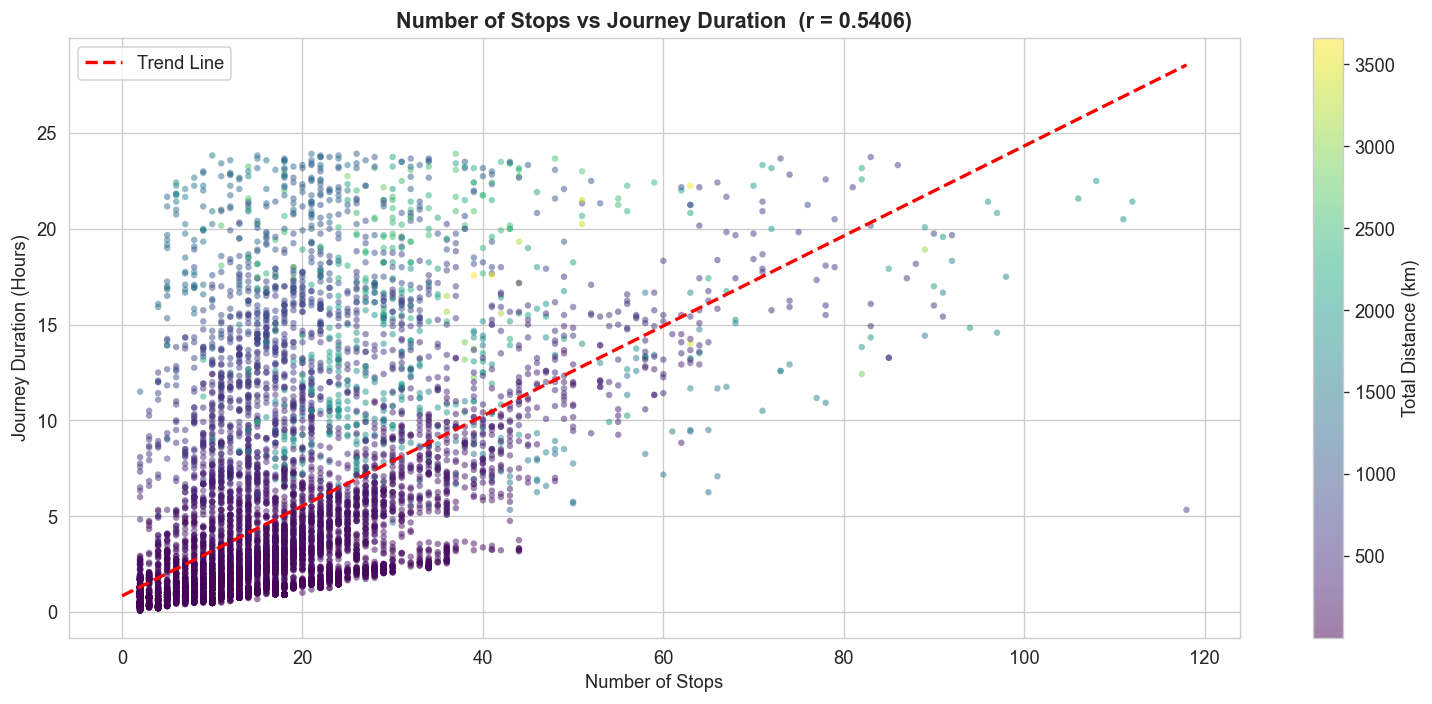

✅ Chart 6 saved!


In [9]:
# --- Chart 6: Stops vs Duration Scatter ---
fig, ax = plt.subplots(figsize=(13, 6))

scatter = ax.scatter(
    train_master['Num_Stops'],
    train_master['Journey_Duration_Hrs'],
    c=train_master['Total_Distance_km'],
    cmap='viridis',
    alpha=0.5, s=15, edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Total Distance (km)')

# Regression line
z2 = np.polyfit(train_master['Num_Stops'], train_master['Journey_Duration_Hrs'], 1)
p2 = np.poly1d(z2)
x2 = np.linspace(0, train_master['Num_Stops'].max(), 200)
ax.plot(x2, p2(x2), 'r--', linewidth=2, label='Trend Line')

corr2 = train_master['Num_Stops'].corr(train_master['Journey_Duration_Hrs'])
ax.set_title(f'Number of Stops vs Journey Duration  (r = {corr2:.4f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Stops')
ax.set_ylabel('Journey Duration (Hours)')
ax.legend()

plt.tight_layout()
plt.savefig('Level4_Chart6_Stops_vs_Duration.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 6 saved!')

---
## 💡 Task 4.4 — Patterns Observed from Visual Analysis

In [10]:
# Final summary of visual insights
print('=' * 65)
print('     💡 LEVEL 4 — VISUAL PATTERN INSIGHTS')
print('=' * 65)
print()
print('📊 Chart 1 & 2 — Journey Duration Across Routes:')
print('  → 48.8% trains are SHORT journeys (≤2 hrs)')
print('  → 31.4% are MEDIUM (2–8 hrs)')
print('  → Only 4.1% are VERY LONG (>18 hrs)')
print('  → Avg duration rises consistently with distance bucket')
print('  → Box plot shows large spread in Long & Very Long categories')
print()
print('🚉 Chart 3 & 4 — Station Traffic:')
print('  → CST Mumbai is the busiest with 1,027 unique trains')
print('  → Top 5 stations are all major metro hubs')
print('  → Majority of stations handle very few trains (long tail)')
print('  → Traffic follows a power-law distribution')
print()
print('📈 Chart 5 & 6 — Distance vs Duration:')
print('  → Strong positive correlation: r = 0.80 (Distance vs Duration)')
print('  → Moderate positive correlation: r = 0.54 (Stops vs Duration)')
print('  → Trend line confirms: more distance = more time (linear pattern)')
print('  → Color-coded scatter shows distant trains cluster in upper right')
print('  → Stops vs Duration: trains with 50+ stops are almost always >10 hrs')
print()
print('🤖 ML Model Insight (Preview for Level 5):')
print('  → Distance & Num_Stops will be our 2 best features')
print('  → Linear Regression should perform well (linear trend confirmed)')
print('  → Some outliers exist (trains with unusual speed) — handled in L2')
print()
print('  ✅ All 6 charts saved as PNG files!')
print('  ✅ Ready for Level 5 — ML Model Development!')
print('=' * 65)

     💡 LEVEL 4 — VISUAL PATTERN INSIGHTS

📊 Chart 1 & 2 — Journey Duration Across Routes:
  → 48.8% trains are SHORT journeys (≤2 hrs)
  → 31.4% are MEDIUM (2–8 hrs)
  → Only 4.1% are VERY LONG (>18 hrs)
  → Avg duration rises consistently with distance bucket
  → Box plot shows large spread in Long & Very Long categories

🚉 Chart 3 & 4 — Station Traffic:
  → CST Mumbai is the busiest with 1,027 unique trains
  → Top 5 stations are all major metro hubs
  → Majority of stations handle very few trains (long tail)
  → Traffic follows a power-law distribution

📈 Chart 5 & 6 — Distance vs Duration:
  → Strong positive correlation: r = 0.80 (Distance vs Duration)
  → Moderate positive correlation: r = 0.54 (Stops vs Duration)
  → Trend line confirms: more distance = more time (linear pattern)
  → Color-coded scatter shows distant trains cluster in upper right
  → Stops vs Duration: trains with 50+ stops are almost always >10 hrs

🤖 ML Model Insight (Preview for Level 5):
  → Distance & Num_S